<a href="https://colab.research.google.com/github/Zinc-zn/MachineLearning2026/blob/main/KUIS1_244107020240_MOCHAMMAD_RIJAL_DZAKI_RIFKI_AFIFUDIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [8]:
# 1. Inspeksi profile data (informasi kolom, tipe data, dll)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [9]:
# Mengganti simbol '?' dengan np.nan pada seluruh dataframe
df.replace('?', np.nan, inplace=True)

In [10]:
# 2. Mengecek variabel apa saja yang memiliki missing value dan jumlahnya
missing_values = df.isnull().sum()
print("Variabel dengan missing value dan jumlahnya:")
print(missing_values[missing_values > 0])

Variabel dengan missing value dan jumlahnya:
workclass         2799
occupation        2809
native-country     857
dtype: int64


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [11]:
# 1. proses data imputation (menggunakan modus untuk data kualitatif)
cols_with_missing = df.columns[df.isnull().any()]

In [12]:
for col in cols_with_missing:
    # Mengambil nilai modus pertama dari kolom tersebut
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

/tmp/ipykernel_1899/1209919822.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


In [13]:
# 2. Cek kembali apakah masih terdapat data yang hilang
print("Sisa missing value setelah imputasi:")
print(df.isnull().sum())

Sisa missing value setelah imputasi:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [18]:
# Inspeksi semua fitur kualitatif
categorical_cols = df.select_dtypes(include=['category', 'object']).columns

In [19]:
print("Inspeksi Nilai Unik Sebelum Penyesuaian:\n")
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")

Inspeksi Nilai Unik Sebelum Penyesuaian:

--- workclass ---
workclass
Private             36705
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64 

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64 

--- marital-status ---
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64 

---

In [20]:
# Penyesuaian 1: Memperbaiki duplikasi karena kesalahan penulisan pada kolom 'income'
df['income'] = df['income'].replace({'>50K.': '>50K', '<=50K.': '<=50K'})

In [21]:
# Penyesuaian 2: Mengganti kategori yang berpotensi tidak jelas menjadi 'Others'
# (Contoh jika ada kategori 'Without-pay' atau 'Never-worked' di workclass yang sangat minoritas)
# df['workclass'] = df['workclass'].replace(['Without-pay', 'Never-worked'], 'Others')

print("Verifikasi Nilai Unik Kolom 'income' Setelah Penyesuaian:")
print(df['income'].value_counts())

Verifikasi Nilai Unik Kolom 'income' Setelah Penyesuaian:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

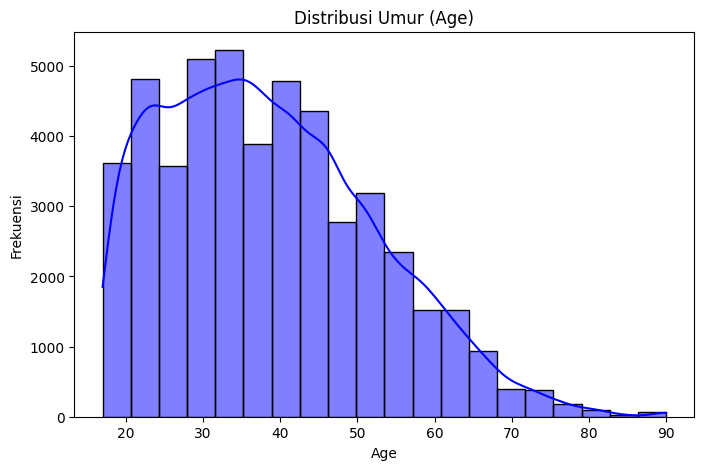

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=20, kde=True, color='blue')
plt.title('Distribusi Umur (Age)')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()

/tmp/ipykernel_1899/2794783018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='education', order=df['education'].value_counts().index, palette='viridis')


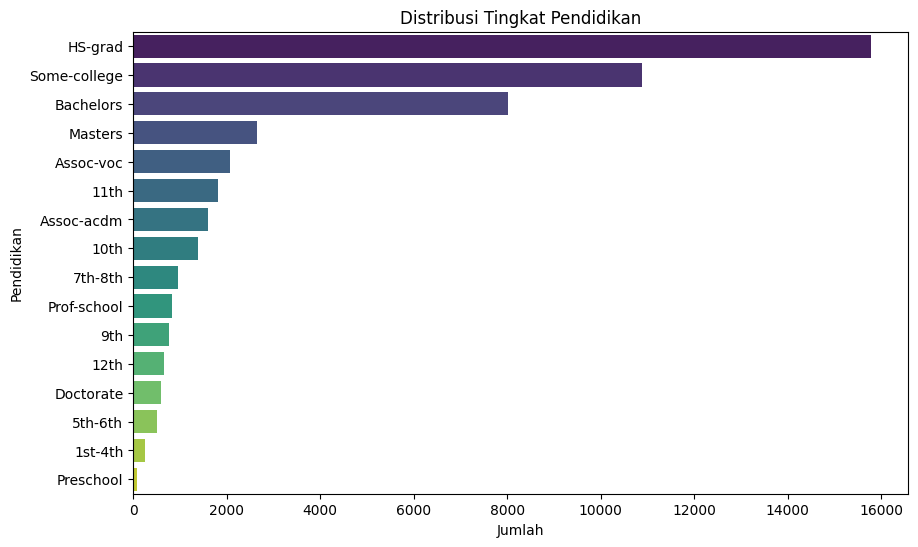

In [23]:
plt.figure(figsize=(10, 6))
# Menggunakan y='education' agar label terbaca dengan jelas (horizontal barchart)
sns.countplot(data=df, y='education', order=df['education'].value_counts().index, palette='viridis')
plt.title('Distribusi Tingkat Pendidikan')
plt.xlabel('Jumlah')
plt.ylabel('Pendidikan')
plt.show()

/tmp/ipykernel_1899/2886216563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2')


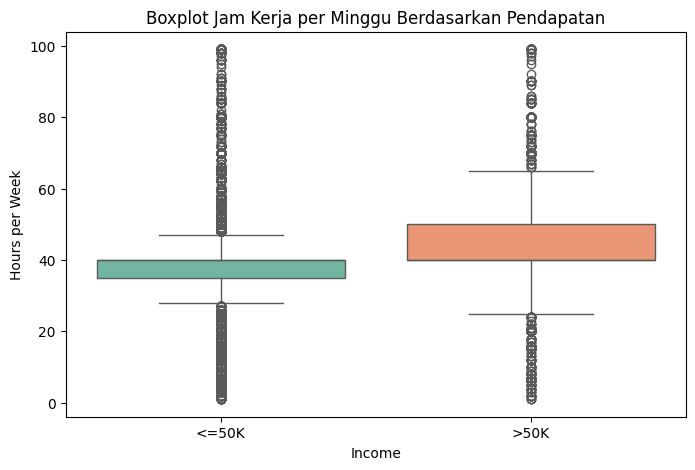

In [24]:
# Cell 3
plt.figure(figsize=(8, 5))
# Sesuai data, nama kolomnya adalah 'hours-per-week' dengan tanda hubung
sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2')
plt.title('Boxplot Jam Kerja per Minggu Berdasarkan Pendapatan')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

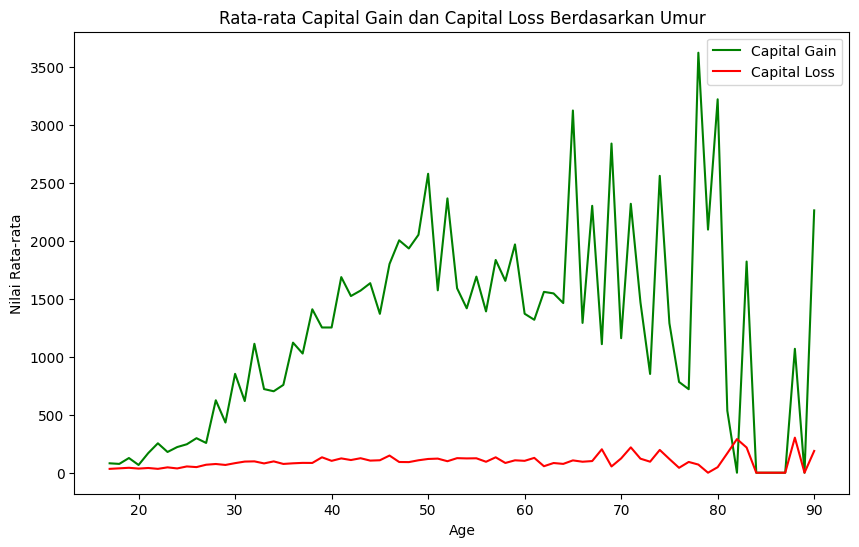

In [25]:
plt.figure(figsize=(10, 6))
# Melakukan agregasi (rata-rata) berdasarkan umur agar garis lebih mudah dibaca
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

sns.lineplot(data=age_capital, x='age', y='capital-gain', label='Capital Gain', color='green')
sns.lineplot(data=age_capital, x='age', y='capital-loss', label='Capital Loss', color='red')

plt.title('Rata-rata Capital Gain dan Capital Loss Berdasarkan Umur')
plt.xlabel('Age')
plt.ylabel('Nilai Rata-rata')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [26]:
'''

1. Fenomena pada distribusi data 'age':
   Berdasarkan histogram yang dihasilkan, distribusi data 'age' (umur) cenderung tidak simetris dan mengalami skewness positif (menceng ke kanan / right-skewed). Sebagian besar populasi dalam dataset memusat pada kelompok usia produktif awal hingga pertengahan (sekitar 20 hingga 40-an tahun), kemudian frekuensinya menurun secara perlahan seiring bertambahnya usia.

2. Strategi imputasi untuk data yang hilang pada 'age':
   Karena distribusi data 'age' menceng ke kanan (right-skewed), strategi imputasi yang paling tepat adalah menggunakan nilai **Median** (nilai tengah). Penggunaan Mean (rata-rata) tidak disarankan karena mean sangat sensitif dan rentan tertarik oleh nilai ekstrem (outlier) pada rentang usia tua. Sebaliknya, median jauh lebih tangguh (robust) dalam memberikan representasi pemusatan data untuk distribusi yang asimetris.

3. Jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hours-per-week':
   - Pada boxplot, nilai 'hours-per-week' sangat terpusat di angka 40 jam/minggu (titik median).
   - Hal ini menyebabkan banyaknya variasi jam kerja di luar 40 jam (seperti pekerja paruh waktu atau pekerja lembur) terdeteksi sebagai outlier.
   - Kategori pendapatan **'<=50K'** memiliki jumlah absolut outlier yang paling banyak. Ini disebabkan oleh dua faktor utama: rentang jam kerjanya sangat bervariasi (banyak yang kurang dari 40 jam), dan proporsi kelas kelas '<=50K' jauh mendominasi keseluruhan data (sekitar 75%) dibandingkan kelas '>50K'.
'''

"\n\n1. Fenomena pada distribusi data 'age':\n   Berdasarkan histogram yang dihasilkan, distribusi data 'age' (umur) cenderung tidak simetris dan mengalami skewness positif (menceng ke kanan / right-skewed). Sebagian besar populasi dalam dataset memusat pada kelompok usia produktif awal hingga pertengahan (sekitar 20 hingga 40-an tahun), kemudian frekuensinya menurun secara perlahan seiring bertambahnya usia.\n\n2. Strategi imputasi untuk data yang hilang pada 'age':\n   Karena distribusi data 'age' menceng ke kanan (right-skewed), strategi imputasi yang paling tepat adalah menggunakan nilai **Median** (nilai tengah). Penggunaan Mean (rata-rata) tidak disarankan karena mean sangat sensitif dan rentan tertarik oleh nilai ekstrem (outlier) pada rentang usia tua. Sebaliknya, median jauh lebih tangguh (robust) dalam memberikan representasi pemusatan data untuk distribusi yang asimetris.\n\n3. Jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hours-per-week':\n   - Pada boxplot

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [27]:
# Mengubah variabel 'sex': Male menjadi 1, Female menjadi 0
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

# Mengubah variabel target 'income': '>50K' menjadi 1, '<=50K' menjadi 0
df['income'] = df['income'].map({'>50K': 1, '<=50K': 0})

# Cek kembali hasil encoding
print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

                     age  education-num  hours-per-week  capital-gain  \
age             1.000000       0.030940        0.071558      0.077229   
education-num   0.030940       1.000000        0.143689      0.125146   
hours-per-week  0.071558       0.143689        1.000000      0.082157   
capital-gain    0.077229       0.125146        0.082157      1.000000   
capital-loss    0.056944       0.080972        0.054467     -0.031441   
income          0.230369       0.332613        0.227687      0.223013   

                capital-loss    income  
age                 0.056944  0.230369  
education-num       0.080972  0.332613  
hours-per-week      0.054467  0.227687  
capital-gain       -0.031441  0.223013  
capital-loss        1.000000  0.147554  
income              0.147554  1.000000  


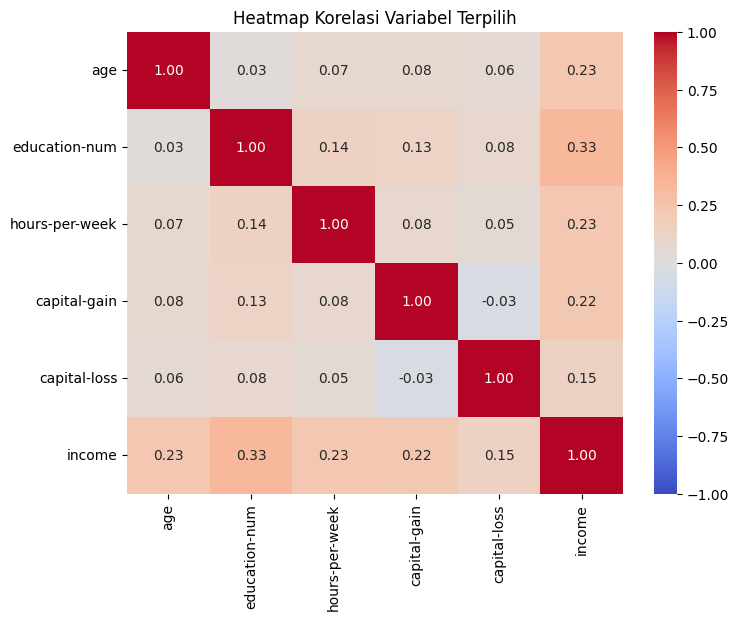

In [28]:
# Memilih variabel numerik yang diminta
num_vars = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']

# Menghitung matriks korelasi menggunakan metode Pearson
correlation_matrix = df[num_vars].corr()

# Tampilkan hasil perhitungan korelasi
print(correlation_matrix)

# Plot Heatmap agar mudah dibaca
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Variabel Terpilih')
plt.show()

In [ ]:
'''
1. Korelasi Terhadap Target 'income':
   - 'education-num' (durasi/jenjang pendidikan) dan 'age' (umur) memiliki korelasi positif yang paling kuat terhadap 'income' (umumnya r berada di atas 0.20 hingga 0.30+). Ini mengindikasikan bahwa semakin lama seseorang menempuh pendidikan dan semakin bertambah usianya (biasanya identik dengan bertambahnya pengalaman kerja), kecenderungan untuk mendapatkan gaji >50K semakin besar.
   - 'hours-per-week' dan 'capital-gain' juga menunjukkan korelasi positif yang moderat terhadap income. Pekerja yang bekerja dengan jam lebih panjang atau yang meraup untung modal (capital gain) cenderung mendapatkan kelas pendapatan >50K.

2. Hubungan Antar Fitur (Multikolinearitas):
   - Korelasi antar fitur independen (misalnya 'age' terhadap 'hours-per-week', atau 'education-num' terhadap 'capital-gain') rata-rata cukup rendah.
   - Hal ini merupakan indikasi yang baik jika kita ingin membangun model Machine Learning (seperti regresi logistik), karena dataset tidak mengidap multikolinearitas yang serius di antara variabel numerik ini.
'''

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [29]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


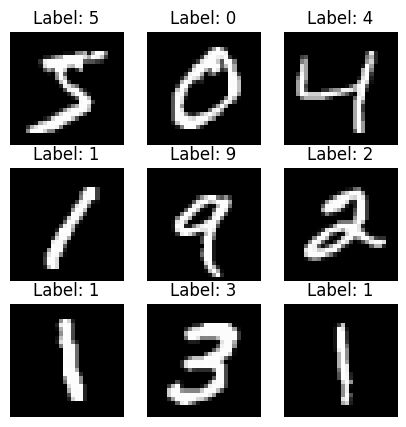

In [30]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

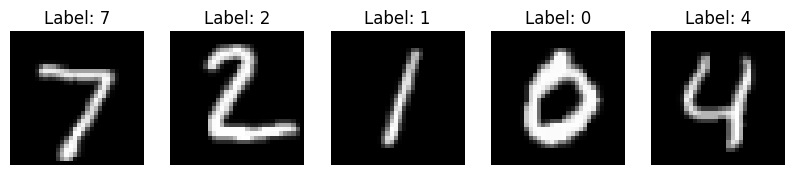

Dimensi data setelah upsampling: (10000, 32, 32)


In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membuat array kosong untuk menampung hasil upsampling (10000 data, ukuran 32x32)
X_test_resized = np.zeros((X_test.shape[0], 32, 32))

# Melakukan upsampling dengan iterasi pada seluruh data test
for i in range(X_test.shape[0]):
    # Mengubah ukuran citra menjadi 32x32 piksel
    X_test_resized[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_LINEAR)

# 2. Menampilkan 5 data hasil proses upsampling
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_resized[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.show()

print("Dimensi data setelah upsampling:", X_test_resized.shape)

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [32]:
# Melakukan normalisasi nilai citra ke rentang 0.0 - 1.0
X_test_norm = X_test_resized / 255.0

# Memastikan hasil normalisasi
print("Nilai minimum piksel:", X_test_norm.min())
print("Nilai maksimum piksel:", X_test_norm.max())

Nilai minimum piksel: 0.0
Nilai maksimum piksel: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [33]:
# Membuat holder array kosong berukuran (10000, 1024)
# 1024 didapat dari ukuran citra 32 * 32
X_test_flat = np.zeros((X_test_norm.shape[0], 1024))

# Melakukan iterasi dan meratakan (flatten) matriks 2D menjadi 1D
for i in range(X_test_norm.shape[0]):
    X_test_flat[i] = X_test_norm[i].flatten()

# Pengecekan dimensi akhir
print("Dimensi data test awal:", X_test_norm.shape)
print("Dimensi data test setelah flatten:", X_test_flat.shape)

Dimensi data test awal: (10000, 32, 32)
Dimensi data test setelah flatten: (10000, 1024)
